In [1]:
import pandas as pd

df = pd.read_csv("anime_dataset.csv")

In [2]:
df.columns

Index(['mal_id', 'title', 'title_english', 'title_japanese', 'type', 'source',
       'episodes', 'status', 'airing', 'aired_from', 'aired_to', 'duration',
       'rating', 'score', 'scored_by', 'rank', 'popularity', 'members',
       'favorites', 'season', 'year', 'studios', 'producers', 'licensors',
       'genres', 'themes', 'demographics', 'synopsis', 'image_url'],
      dtype='object')

In [3]:
df.head()

,mal_id,title,title_english,title_japanese,type,source,episodes,status,airing,aired_from,...,season,year,studios,producers,licensors,genres,themes,demographics,synopsis,image_url
0,1,Cowboy Bebop,Cowboy Bebop,カウボーイビバップ,TV,Original,26.0,Finished Airing,False,1998-04-03,...,spring,1998.0,Sunrise,Bandai Visual|Victor Entertainment|Audio Plann...,Funimation,Action|Award Winning|Sci-Fi,Adult Cast|Space,NaN,"Crime is timeless. By the year 2071, humanity ...",https://myanimelist.net/images/anime/4/19644.jpg
1,5,Cowboy Bebop: Tengoku no Tobira,Cowboy Bebop: The Movie,カウボーイビバップ 天国の扉,Movie,Original,1.0,Finished Airing,False,2001-09-01,...,NaN,NaN,Bones,Sunrise|Bandai Visual,Sony Pictures Entertainment|Funimation,Action|Sci-Fi,Adult Cast|Space,NaN,"Another day, another bounty—such is the life o...",https://myanimelist.net/images/anime/1439/9348...
2,6,Trigun,Trigun,トライガン,TV,Manga,26.0,Finished Airing,False,1998-04-01,...,spring,1998.0,Madhouse,Victor Entertainment|Arts Pro,Funimation,Action|Adventure|Sci-Fi,Adult Cast,Shounen,"Vash the Stampede is the man with a $$60,000,0...",https://myanimelist.net/images/anime/1130/1200...
3,7,Witch Hunter Robin,Witch Hunter Robin,Witch Hunter ROBIN (ウイッチハンターロビン),TV,Original,26.0,Finished Airing,False,2002-07-03,...,summer,2002.0,Sunrise,Bandai Visual|Dentsu|Victor Entertainment,Funimation|Bandai Entertainment,Action|Drama|Mystery|Supernatural,Detective,NaN,"Though hidden away from the general public, Wi...",https://myanimelist.net/images/anime/10/19969.jpg
4,8,Bouken Ou Beet,Beet the Vandel Buster,冒険王ビィト,TV,Manga,52.0,Finished Airing,False,2004-09-30,...,fall,2004.0,Toei Animation,TV Tokyo|Dentsu,Illumitoon Entertainment,Action|Adventure|Fantasy,NaN,Shounen,It is the dark century and the people are suff...,https://myanimelist.net/images/anime/7/21569.jpg


仮説
①エピソードが長いほうがストーリー性があり、人気である
②放送年が最近であるほうが人気がある
③放送年が最近であるほうがエピソードが短い傾向がある
→タイパ重視など時代の流れ
④登録人数よりもお気に入り数のほうが人気人数との正の相関が大きい
⑤アニメの数が多いスタジオのほうが評価が高いアニメをつくる
⑥評価が高いほど人気順位が高い

①

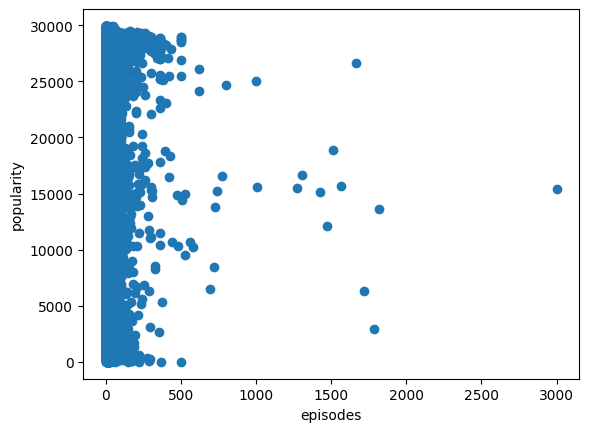

In [4]:
import matplotlib.pyplot as plt
plt.scatter(df['episodes'],df['popularity'])
plt.xlabel("episodes")
plt.ylabel("popularity")
plt.show()

In [5]:
df[["episodes","popularity"]].corr()

,episodes,popularity
episodes,1.000000,0.058488
popularity,0.058488,1.000000


エピソードの長さと人気は弱い正の相関がある
しかし、相関図があまりにも左に寄っているため、エピソードが250以下のもののみで考えてみる

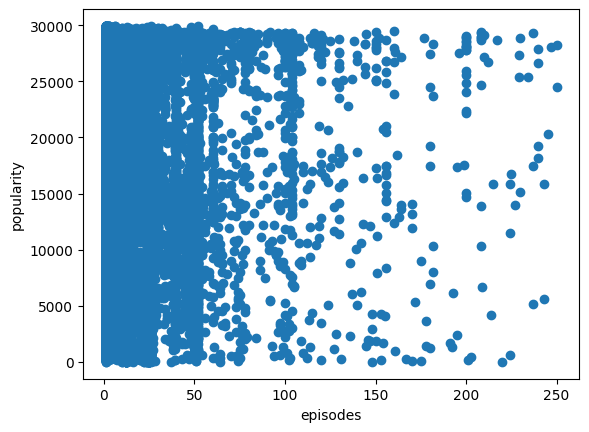

In [6]:
epdf=df[df["episodes"]<=250]
plt.scatter(epdf["episodes"],epdf["popularity"])
plt.xlabel("episodes")
plt.ylabel("popularity")
plt.show()

In [7]:
epdf[["episodes","popularity"]].corr()

,episodes,popularity
episodes,1.000000,0.090111
popularity,0.090111,1.000000


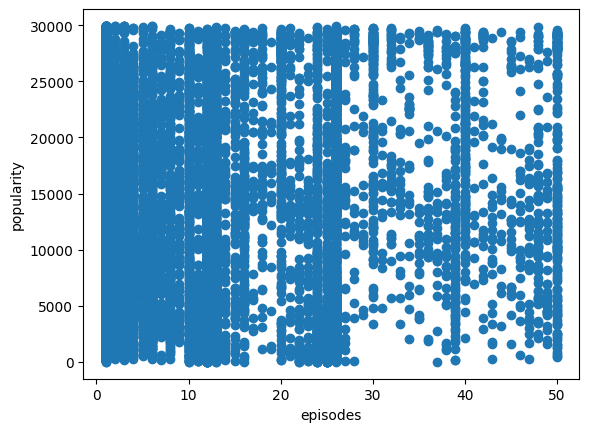

In [8]:
epdf2=df[df["episodes"]<=50]
plt.scatter(epdf2["episodes"],epdf2["popularity"])
plt.xlabel("episodes")
plt.ylabel("popularity")
plt.show()

In [9]:
epdf2[["episodes","popularity"]].corr()

,episodes,popularity
episodes,1.000000,-0.072189
popularity,-0.072189,1.000000


250以下であると正の相関であるが、50以下にすると弱い負の相関になる
これより、長編の漫画はエピソードの長いほうが人気の傾向があるが、短編、中編(50話以下)の漫画は中途半端に長いと人気でない傾向がある

②

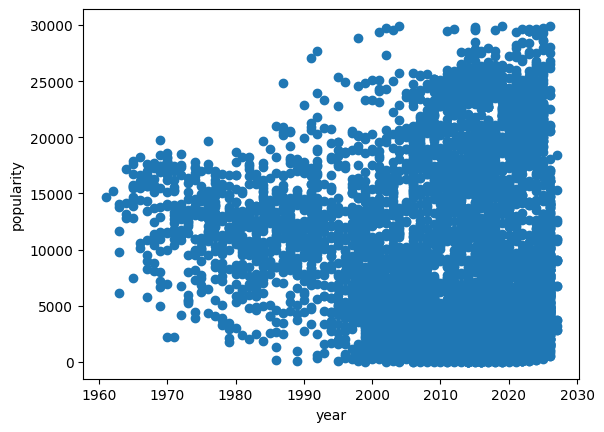

In [10]:
plt.scatter(df["year"],df["popularity"])
plt.xlabel("year")
plt.ylabel("popularity")
plt.show()

In [11]:
df[["year","popularity"]].corr()

,year,popularity
year,1.000000,-0.159876
popularity,-0.159876,1.000000


相関図を見ると右下に集中しており、弱い負の相関があることがわかる
これより、最近のアニメほど人気であるという仮説は誤りである
また、このデータに載るような昔のアニメは人気である可能性が高い

③

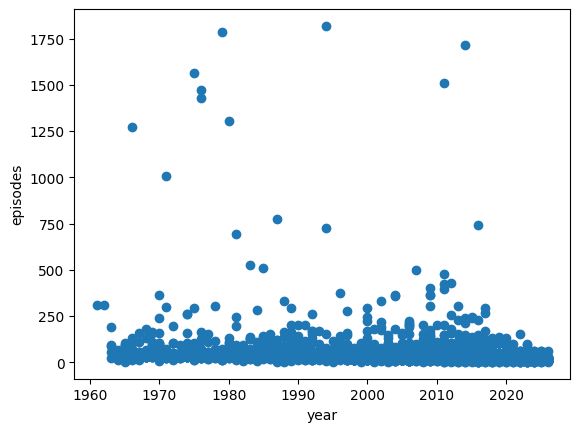

In [12]:
plt.scatter(df["year"],df["episodes"])
plt.xlabel("year")
plt.ylabel("episodes")
plt.show()

In [13]:
df[["year","episodes"]].corr()

,year,episodes
year,1.000000,-0.231611
episodes,-0.231611,1.000000


相関図があまりにも下に集まっているため、エピソードが250より多いものを外れ値として、もう一度相関について考える

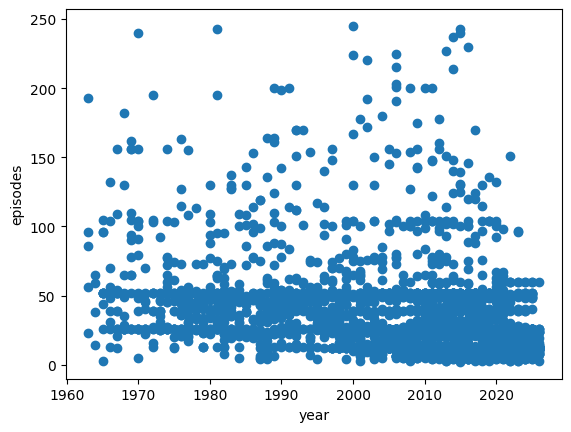

In [14]:
epdf=df[df["episodes"]<=250]
plt.scatter(epdf["year"],epdf["episodes"])
plt.xlabel("year")
plt.ylabel("episodes")
plt.show()

In [15]:
epdf[["year","episodes"]].corr()

,year,episodes
year,1.000000,-0.384848
episodes,-0.384848,1.000000


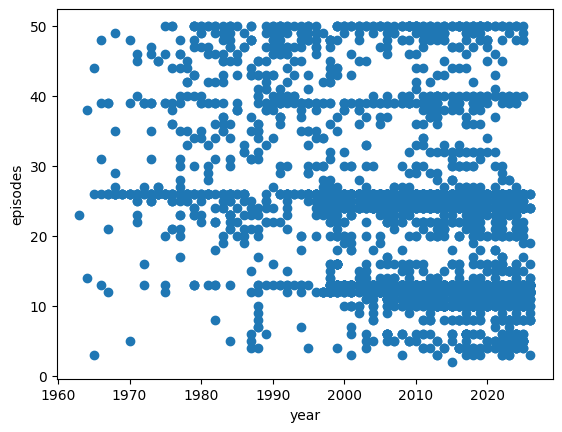

In [16]:
plt.scatter(epdf2["year"],epdf2["episodes"])
plt.xlabel("year")
plt.ylabel("episodes")
plt.show()

In [17]:
epdf2[["year","episodes"]].corr()

,year,episodes
year,1.000000,-0.457211
episodes,-0.457211,1.000000


250話以下、50話以下と対象を減らしていくと、負の相関が強くなる
これより、最近であるほどエピソードが短いという仮説は誤りである可能性が高い

④

お気に入りと人気について

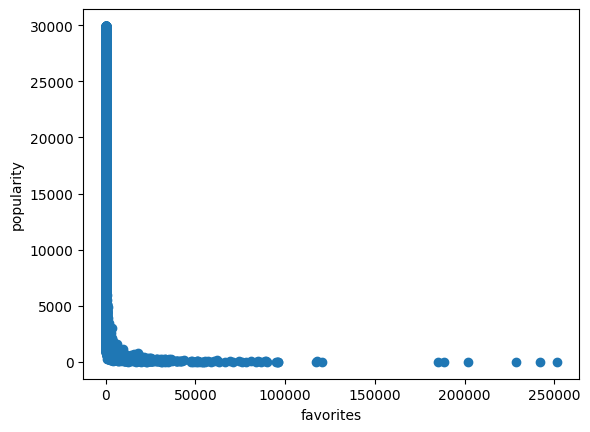

In [18]:
plt.scatter(df["favorites"],df["popularity"])
plt.xlabel("favorites")
plt.ylabel("popularity")
plt.show()

In [19]:
df[["favorites","popularity"]].corr()

,favorites,popularity
favorites,1.000000,-0.157424
popularity,-0.157424,1.000000


In [20]:
df[["favorites"]].mean()

,0
favorites,429.132801


In [21]:
df[["favorites"]].median()

,0
favorites,1.0


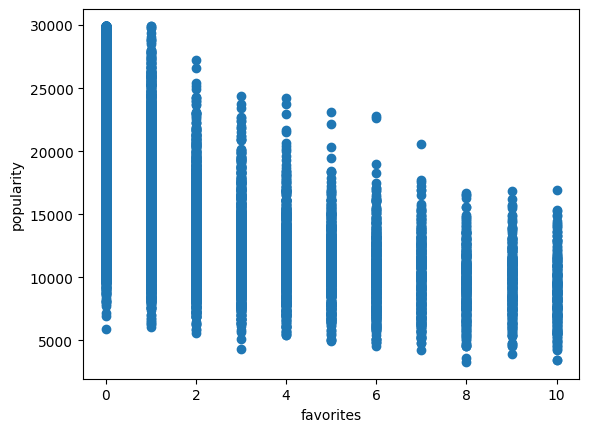

In [22]:
fadf=df[df["favorites"]<=10]
plt.scatter(fadf["favorites"],fadf["popularity"])
plt.xlabel("favorites")
plt.ylabel("popularity")
plt.show()

In [23]:
fadf[["favorites","popularity"]].corr()

,favorites,popularity
favorites,1.000000,-0.648487
popularity,-0.648487,1.000000


登録人数と人気について

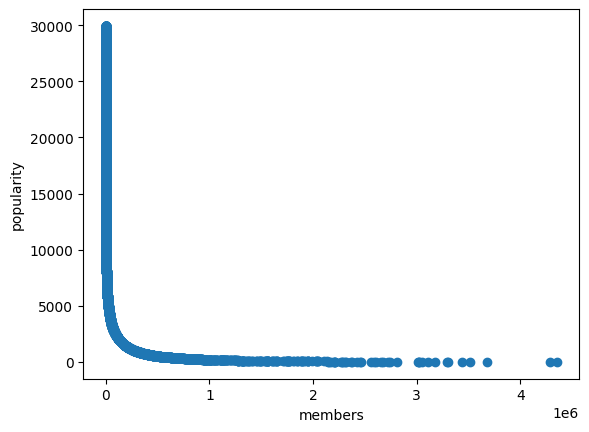

In [24]:
plt.scatter(df["members"],df["popularity"])
plt.xlabel("members")
plt.ylabel("popularity")
plt.show()

In [25]:
df[["members","popularity"]].corr()

,members,popularity
members,1.000000,-0.360872
popularity,-0.360872,1.000000


In [26]:
df[["members"]].mean()

,0
members,39013.961829


In [27]:
df[["members"]].median()

,0
members,1088.0


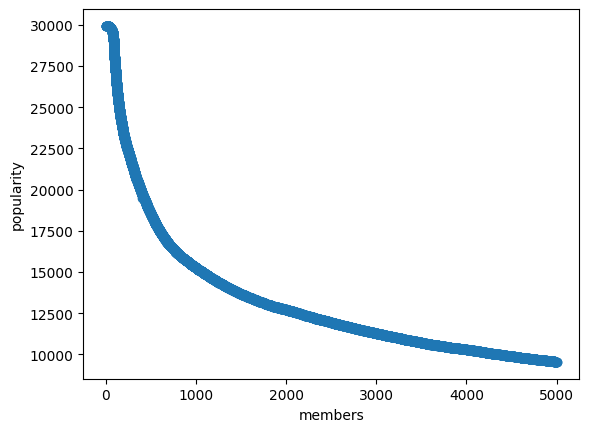

In [28]:
memdf=df[df["members"]<=5000]
plt.scatter(memdf["members"],memdf["popularity"])
plt.xlabel("members")
plt.ylabel("popularity")
plt.show()

In [29]:
memdf[["members","popularity"]].corr()

,members,popularity
members,1.00000,-0.82595
popularity,-0.82595,1.00000


お気に入りの数、登録数ともに人気と強い負の相関がある
また、登録数のほうが負の相関が強い
負の相関になる理由は他の第三の要素によるものだと考えられる

⑤

In [30]:
df["studios"].value_counts()

,count
studios,
Toei Animation,895
Sunrise,562
J.C.Staff,418
TMS Entertainment,380
Shanghai Animation Film Studio,342
...,...
Shen Fu Wenhua,1
SynergySP|The Answer Studio,1
Mofac Studio,1


In [31]:
studio_count = df["studios"].value_counts()

In [32]:
studio_score=df.groupby("studios")["score"].mean()

In [34]:
studio_df = pd.DataFrame({"count": studio_count,"score": studio_score
})
studio_df.head()

,count,score
studios,,
100studio,4,6.570000
10Gauge,6,6.720000
10Gauge|Studio DURIAN,1,7.720000
1IN,1,NaN
2:10 Animation,16,6.768889


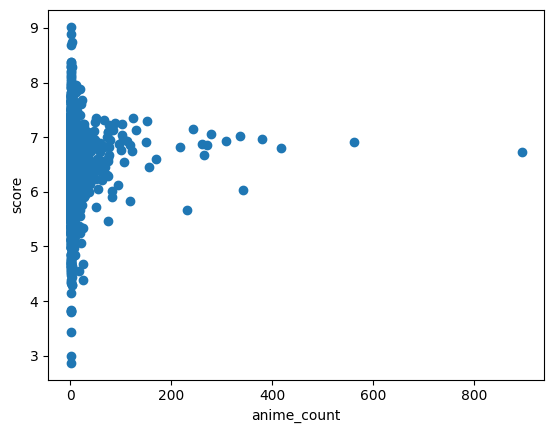

In [36]:
plt.scatter(studio_df["count"],studio_df["score"])
plt.xlabel("anime_count")
plt.ylabel("score")
plt.show()

In [38]:
studio_df[["count","score"]].corr()

,count,score
count,1.000000,0.079384
score,0.079384,1.000000


In [39]:
studio_df["count"].median()

2.0

In [40]:
studio_df["count"].mean()

np.float64(8.983159980188212)

In [41]:
studio_dfneo=studio_df[studio_df["count"]<=50]

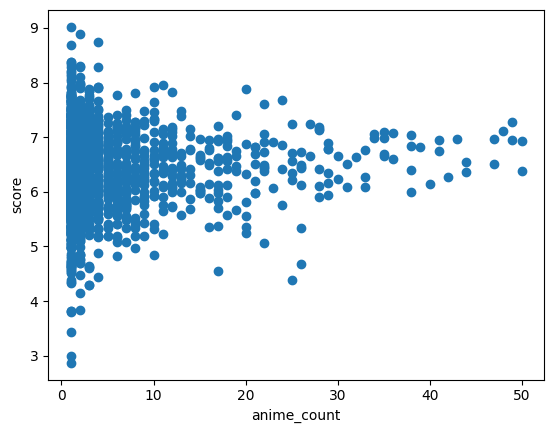

In [42]:
plt.scatter(studio_dfneo["count"],studio_dfneo["score"])
plt.xlabel("anime_count")
plt.ylabel("score")
plt.show()

In [43]:
studio_dfneo[["count","score"]].corr()

,count,score
count,1.000000,0.065564
score,0.065564,1.000000


これらより、スタジオのアニメの数とアニメの評価の平均は弱い正の相関があり、大きい有名なスタジオが出すアニメほど人気であるという仮説は否定できない。また、弱い相関であることから、スタジオのアニメの多さが人気に大きな影響を与えているとは言えない

⑥

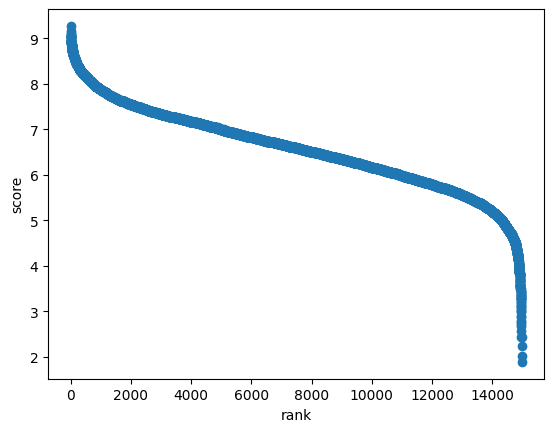

In [44]:
plt.scatter(df["rank"],df["score"])
plt.xlabel("rank")
plt.ylabel("score")
plt.show()

In [47]:
df[["rank","score"]].corr()

,rank,score
rank,1.000000,-0.974556
score,-0.974556,1.000000


相関図と相関係数より、ランクの低さと評価は強い負の相関があることがわかる。これより、ランクが高いほど評価が高いという仮説は正しい